**Code Explanation:**
**Path Setup**: Adds the `code` directory to the Python path.

In [4]:
import sys
import os
# Add the sibling 'code' directory to the Python path
sys.path.append(os.path.abspath('../code'))


# Experiment 02 - Coexistence, uniform persistence, and Lyapunov functions

Paper sections reproduced: Section 3, Theorem 3.1, Theorem 3.2, Theorem 3.4.

This notebook visualizes the coexistence equilibrium `P3`, tests several initial conditions, and plots Lyapunov functions used for global stability of boundary subsystems.


**Code Explanation:**
**Imports**: Imports numerical solvers, plotting functions, and the function `find_P3` to calculate the interior equilibrium.

In [5]:
from utils import monod_inv
from simulation import simulate
from equilibria import find_P3_2D as find_P3
from plotting import plot_timeseries

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root, brentq
from model import ChemostatModel

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

## Experiment 1: coexistence equilibrium P3

Equivalent to Theorem 3.4 and the discussion after it. All species remain positive in the long run.


**Code Explanation:**
**Coexistence at $P_3$ (Theorem 3.4)**: Simulates the system with parameters that support all species. A 3D phase portrait in $x$-$y$-$z$ space visualizes the uniform persistence of the system, showing the trajectory spiraling into the strictly positive interior equilibrium $P_3$.

P3 = [0.06685199 1.62912887 0.16666667 0.39632626]


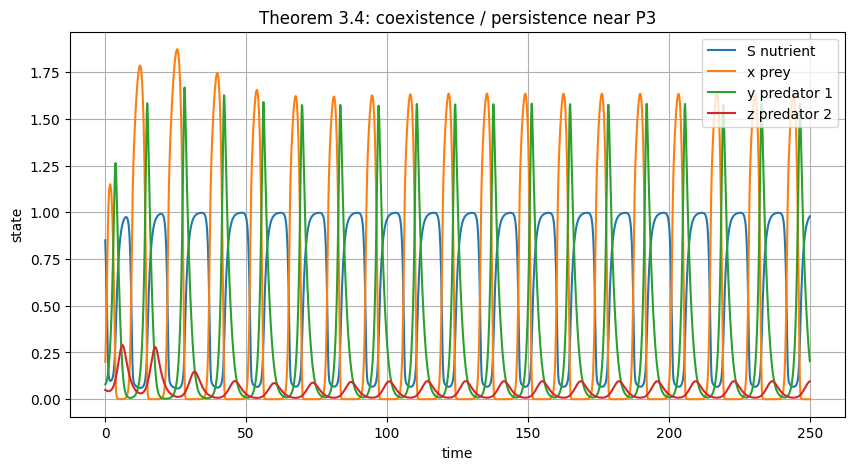

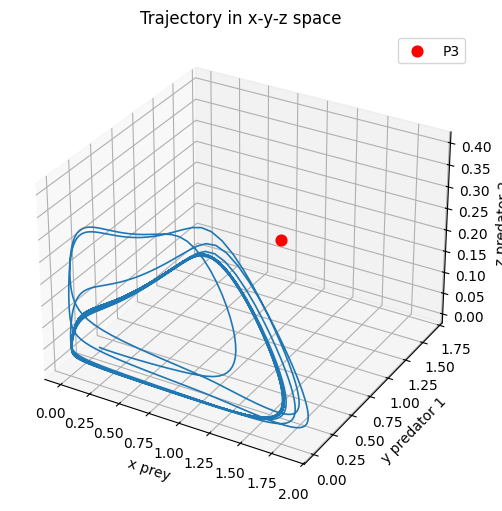

In [6]:
p = dict(a1=4.0, b1=0.4, a2=2.0, b2=0.3, a3=1.4, b3=0.3, D1=0.4, D2=0.5, D3=0.5)
P3 = find_P3(p)
print("P3 =", P3)

sol = simulate(p, U0=(0.85, 0.2, 0.08, 0.05), T=250)
t, S, x, y, z = plot_timeseries(sol, "Theorem 3.4: coexistence / persistence near P3")
vals = np.array([S, x, y, z])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(vals[1], vals[2], vals[3], lw=1.2)
ax.scatter([P3[1]], [P3[2]], [P3[3]], color="red", s=60, label="P3")
ax.set_xlabel("x prey")
ax.set_ylabel("y predator 1")
ax.set_zlabel("z predator 2")
ax.set_title("Trajectory in x-y-z space")
ax.legend()
plt.show()

## Experiment 2: uniform persistence from many initial conditions

Equivalent to Theorem 3.4. We start from multiple positive initial states and inspect the long-run lower envelope of `x,y,z`.


**Code Explanation:**
**Uniform Persistence Check**: Simulates the model from several different initial conditions. By plotting the minimum population level $\min(x(t), y(t), z(t))$ over time, it visually demonstrates that the populations are robustly bounded away from extinction, reinforcing the uniform persistence proven in Theorem 3.4.

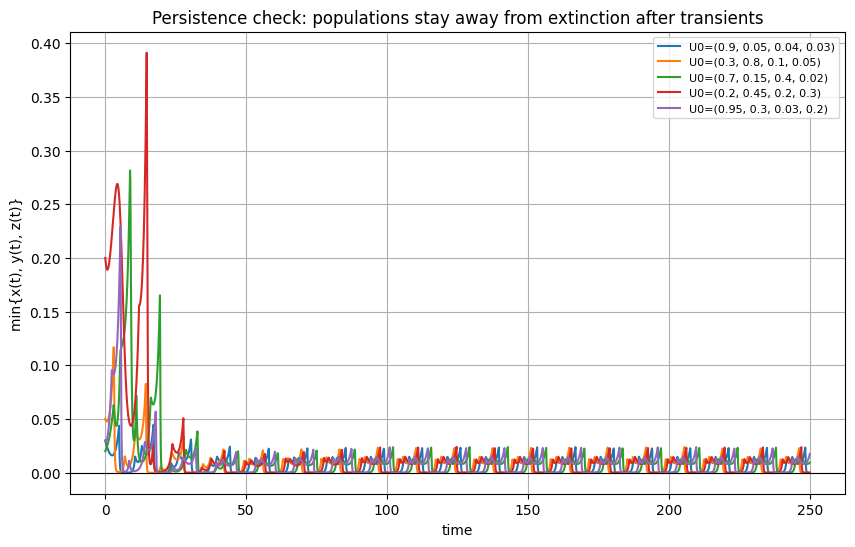

In [7]:
initial_conditions = [
    (0.90, 0.05, 0.04, 0.03),
    (0.30, 0.80, 0.10, 0.05),
    (0.70, 0.15, 0.40, 0.02),
    (0.20, 0.45, 0.20, 0.30),
    (0.95, 0.30, 0.03, 0.20),
]

plt.figure(figsize=(10, 6))
for U0 in initial_conditions:
    sol = simulate(p, U0=U0, T=250)
    t = np.linspace(0, 250, 2500)
    vals = sol.sol(t)
    lower = np.min(vals[1:4], axis=0)
    plt.plot(t, lower, label=f"U0={U0}")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("time")
plt.ylabel("min{x(t), y(t), z(t)}")
plt.title("Persistence check: populations stay away from extinction after transients")
plt.legend(fontsize=8)
plt.show()

## Experiment 3: Lyapunov function for P1

Equivalent to Theorem 3.1. The paper uses a quadratic Lyapunov function on the `(S,x)` subsystem. Here we plot it along a trajectory when P1 is stable.


**Code Explanation:**
**Lyapunov Function for $P_1$ (Theorem 3.1)**: Computes the equilibrium $P_1$ and evaluates the Lyapunov function $V(S,x) = 0.5(S-S_1)^2 + 0.5(x-x_1)^2$ along a simulated trajectory. The plot shows $V(S,x)$ monotonically decreasing toward a stable minimum, illustrating the global asymptotic stability of the $P_1$ subsystem.

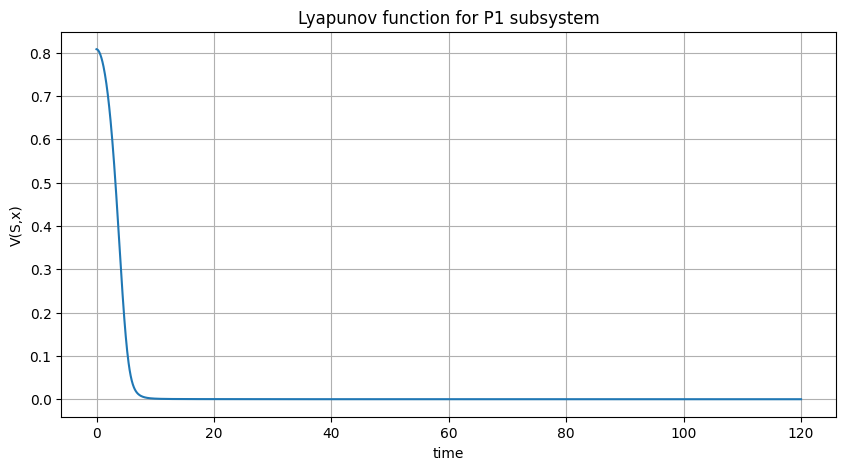

P1 = (0.21538461538461537, 1.120879120879121, 0, 0) final V = 1.7686071342207996e-07


In [8]:
p_P1 = dict(a1=2.0, b1=0.4, a2=0.6, b2=0.5, a3=1.0, b3=0.4, D1=0.7, D2=0.45, D3=0.5)
S1 = monod_inv(p_P1["D1"], p_P1["a1"], p_P1["b1"])
x1 = (1 - S1) / p_P1["D1"]
sol = simulate(p_P1, U0=(0.9, 0.05, 0.25, 0.05), T=120)
t = np.linspace(0, 120, 2000)
S, x, y, z = sol.sol(t)
V = 0.5 * (S - S1)**2 + 0.5 * (x - x1)**2

plt.figure()
plt.plot(t, V)
plt.xlabel("time")
plt.ylabel("V(S,x)")
plt.title("Lyapunov function for P1 subsystem")
plt.show()

print("P1 =", (S1, x1, 0, 0), "final V =", V[-1])

## Experiment 4: Lyapunov function for P2

Equivalent to Theorem 3.2. The paper uses an entropy-like term for nutrient and quadratic terms for prey and predator 1.


**Code Explanation:**
**Lyapunov Function for $P_2$ (Theorem 3.2)**: Calculates the $P_2$ boundary equilibrium. Evaluates a complex Lyapunov function $W(S,x,y)$ (similar to Eq. 3.5) along the system's trajectory. The plot confirms that $W(S,x,y)$ continuously decreases over time, demonstrating the global asymptotic stability of $P_2$ in the $S$-$x$-$y$ subspace.

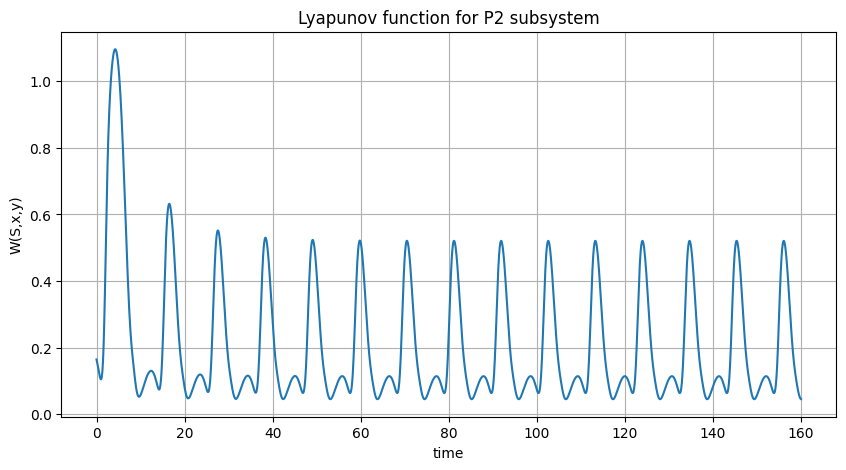

P2 = (0.6056116265125947, 0.24, 0.45731395581234413, 0) final W = 0.04525832979415158


In [9]:
p_P2 = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
x2 = monod_inv(p_P2["D2"], p_P2["a2"], p_P2["b2"])
def eq_S2(S):
    return S + ChemostatModel(p_P2).f1(S) * x2 - 1
S2 = brentq(eq_S2, 1e-8, 1.0)
y2 = x2 * (ChemostatModel(p_P2).f1(S2) - p_P2["D1"]) / p_P2["D2"]

sol = simulate(p_P2, U0=(0.95, 0.1, 0.05, 0.2), T=160)
t = np.linspace(0, 160, 2500)
S, x, y, z = sol.sol(t)
W = S - S2 - S2 * np.log(S / S2) + 0.5 * (x - x2)**2 + 0.5 * (y - y2)**2

plt.figure()
plt.plot(t, W)
plt.xlabel("time")
plt.ylabel("W(S,x,y)")
plt.title("Lyapunov function for P2 subsystem")
plt.show()

print("P2 =", (S2, x2, y2, 0), "final W =", W[-1])